In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

df = pd.read_csv("/content/drive/MyDrive/OnlineRetail.csv", parse_dates=['InvoiceDate'], encoding="ISO-8859-1")
print(df.head())


print(df.head())


print("Veri Boyutu:", df.shape)


print(df.isnull().sum())


df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE 

In [ ]:
# Calculate TotalPrice column
# Assuming 'Quantity' and 'UnitPrice' columns exist
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
# Determine today's date (1 day after the latest date of the dataset)
snapshot_date = df['InvoiceDate'].max() + pd.DateOffset(days=1)

# Calculating RFM metrics
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalPrice': 'sum'                                       # Monetary
}).reset_index()


rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Filter monetary greater than zero
rfm = rfm[rfm['Monetary'] > 0]

In [ ]:
# Recency score (smaller value better)
rfm['RecencyScore'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

# Frequency and Monetary score (bigger is better)
rfm['FrequencyScore'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['MonetaryScore'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# Merge RFM score
rfm['RFM_Score'] = rfm['RecencyScore'].astype(str) + rfm['FrequencyScore'].astype(str) + rfm['MonetaryScore'].astype(str)

In [ ]:
# Create dictionary for segmentation
segment_map = {
    r'[4-5][4-5][4-5]': 'Champions',
    r'[3-4][3-4][3-4]': 'Loyal Customers',
    r'[3-4][1-3][1-3]': 'Potential Loyalists',
    r'[4-5][1-2][1-2]': 'New Customers',
    r'[2-3][2-3][2-3]': 'At Risk',
    r'[1-2][2-3][2-3]': 'Cannot Lose Them',
    r'[1-2][1-2][1-2]': 'Lost'
}

rfm['Segment'] = rfm['RFM_Score'].replace(segment_map, regex=True)

In [ ]:
# Log transformation (to reduce skewness)
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

# Standardization
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

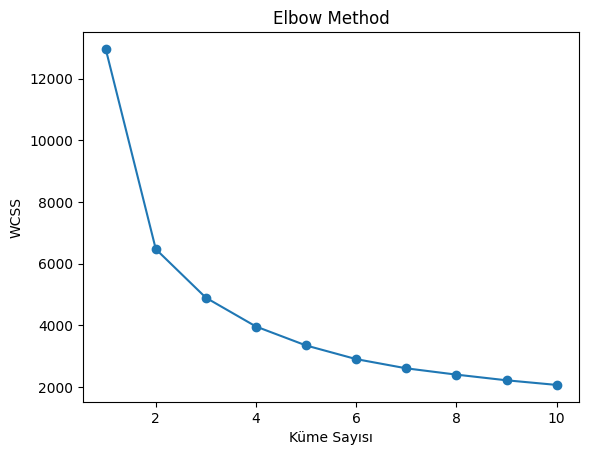

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Küme Sayısı')
plt.ylabel('WCSS')
plt.show()

“This graph is used to determine how many groups (clusters) we need to divide the dataset into. There is a point in the graph where there is a sharp drop, after which it makes little sense to add additional clusters. This 'elbow point' indicates the optimal number of clusters. So it makes sense to divide our data into 3 or 4 clusters.”

In [ ]:
# Optimal number of clusters (example: 4)
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

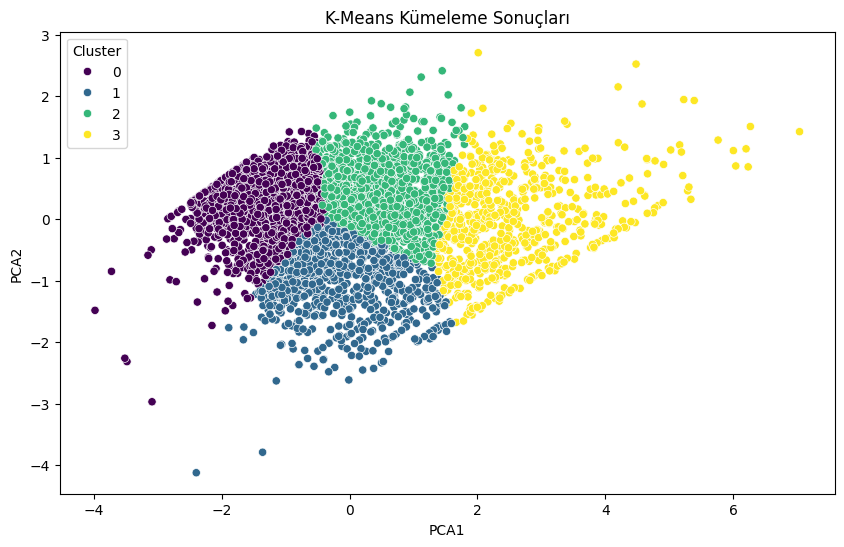

In [ ]:
# Reduction to 2 dimensions with PCA
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = rfm_pca[:,0]
rfm['PCA2'] = rfm_pca[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=rfm, palette='viridis')
plt.title('K-Means Kümeleme Sonuçları')
plt.show()

Kodda PCA, müşteri verisinin en önemli farklılıklarını iki boyuta indirerek görselleştirmeye yardımcı oluyor. Böylece K-Means algoritmasıyla oluşturulan müşteri segmentlerini anlamak daha kolay hale geliyor.

            Recency  Frequency     Monetary  Count
Cluster                                           
0        180.463759   1.515971   353.621119   1628
1         18.483645   2.315421   528.807535    856
2         64.514912   5.176316  1703.481468   1140
3         10.459885  16.846705  7654.687178    698


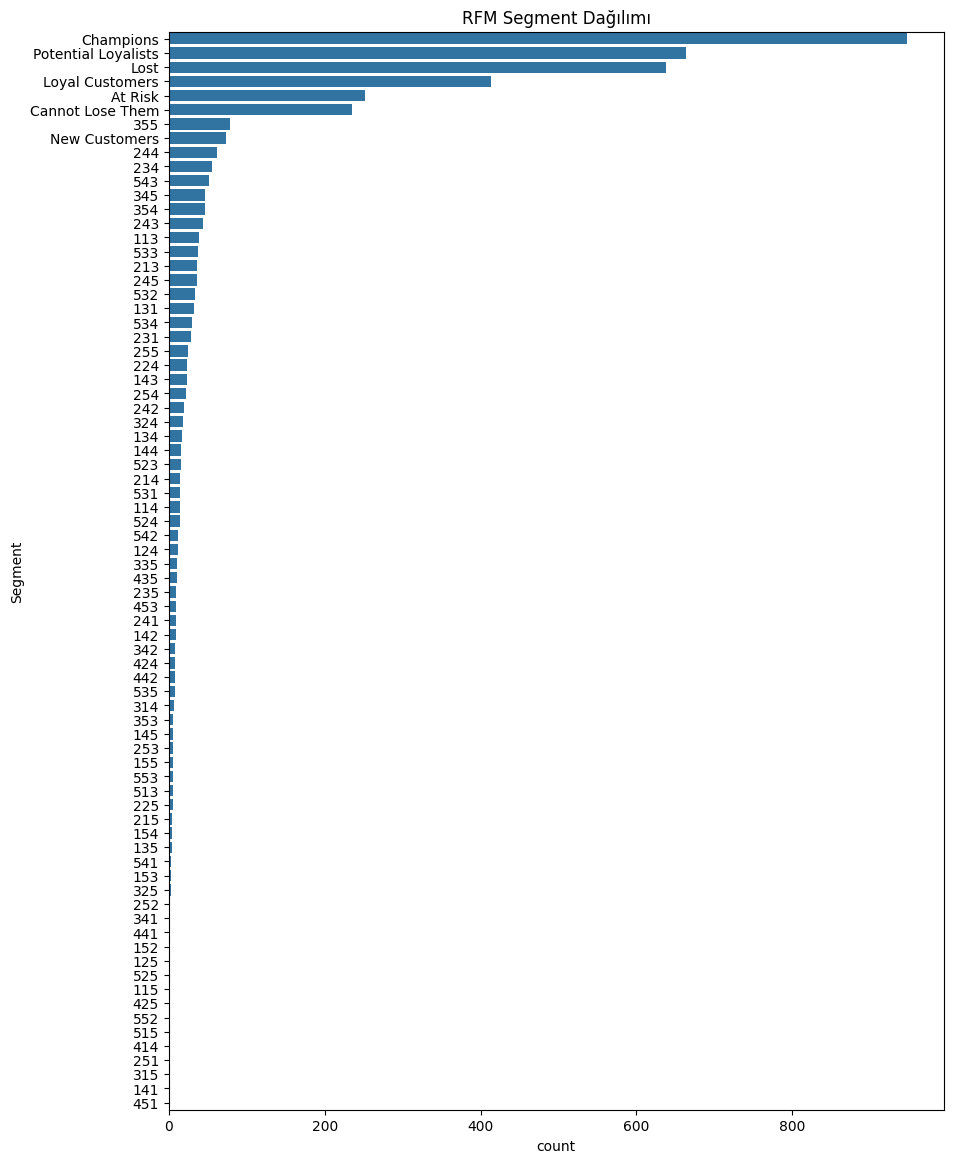

In [ ]:
# Analyzing cluster properties
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'})

print(cluster_summary)

# Distribution of RFM Segments
plt.figure(figsize=(10,14))
sns.countplot(y='Segment', data=rfm, order=rfm['Segment'].value_counts().index)
plt.title('RFM Segment Dağılımı')
plt.show()